# Image compression using SVD

**Chapter V, task 4 of the *Unsupervised Learning / Dimensionality Reduction* project.**

1. Select 3 random grayscale images and load them into a matrix using Python.
2. Decompose the matrix using SVD.
3. Vary the rank, compute a low-rank approximation of the original matrix, and plot the
   recovered image. Use up to 10 different ranks. *What does the singular value spectrum
   look like and how many modes are needed for good image reconstruction?*
4. Plot the distribution of explained variance versus rank. *Explain what "explained
   variance" is.*

**The idea in one line.** A grayscale image **is** a matrix: an $m \times n$ grid of
intensities in $[0, 255]$. Neighbouring rows and columns of a natural photograph look
very much alike, so that matrix — although formally of full rank $\min(m, n)$ — is
*numerically* close to a matrix of much smaller rank. The SVD

$$A = U \Sigma V^{\mathsf T} = \sum_{i=1}^{r} \sigma_i\, u_i v_i^{\mathsf T},
\qquad \sigma_1 \ge \sigma_2 \ge \dots \ge \sigma_r \ge 0$$

writes $A$ as a sum of rank-one "modes" ordered by importance, and the Eckart–Young
theorem says that truncating the sum after $k$ terms gives the *provably best* rank-$k$
approximation of $A$ in the Frobenius norm. Keeping $k$ modes costs $k(m + n + 1)$
numbers instead of $mn$ — that is the compression.

**Images used.** All three are shipped with libraries already installed in the
environment, so the notebook runs completely offline and reproducibly. They were picked
to span very different amounts of spatial detail, because that is exactly what decides
how many modes are needed:

| image | source | character |
|---|---|---|
| `flower` | `sklearn.datasets.load_sample_image("flower.jpg")` | smooth, shallow depth of field, large out-of-focus background |
| `hopper` | `matplotlib` sample data `grace_hopper.jpg` | portrait — moderate detail, strong edges (uniform, insignia) |
| `china`  | `sklearn.datasets.load_sample_image("china.jpg")` | heavily textured — ornate carvings and foliage, high-frequency everywhere |

In [1]:
import pathlib
import time

import cv2
import matplotlib.cbook as cbook
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_sample_image
from sklearn.decomposition import PCA

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Minimal chart style: recessive axes/grid, colors assigned in fixed order.
C_BLUE, C_ORANGE, C_AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED, SURFACE = "#0b0b0b", "#52514e", "#898781", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e8e7e3", "grid.linewidth": 0.8,
    "font.size": 10, "figure.dpi": 100,
})

pd.set_option("display.max_columns", 40)
NB_START = time.perf_counter()

# One colour per image, used consistently in every line chart below.
COLORS = {"flower": C_AQUA, "hopper": C_BLUE, "china": C_ORANGE}

print("RANDOM_STATE =", RANDOM_STATE)

RANDOM_STATE = 42


## 1. Load 3 grayscale images into a matrix

A colour photo is an $m \times n \times 3$ array. We collapse the three channels into one
with the standard ITU-R BT.601 luma weights (what `cv2.COLOR_RGB2GRAY` implements),

$$Y = 0.299\,R + 0.587\,G + 0.114\,B ,$$

which leaves a plain 2-D array of `uint8` intensities — i.e. **a matrix**. Everything
downstream is ordinary linear algebra on that matrix; we cast to `float64` because the SVD
and the reconstructions need real arithmetic, and only clip back to $[0, 255]$ for display.

In [2]:
def to_gray(rgb):
    """RGB uint8 array -> 2-D uint8 grayscale matrix (BT.601 luma)."""
    return cv2.cvtColor(np.asarray(rgb, dtype=np.uint8), cv2.COLOR_RGB2GRAY)


def load_matplotlib_sample(name):
    with cbook.get_sample_data(name) as fh:
        return mpimg.imread(fh)


images = {
    "flower": to_gray(load_sample_image("flower.jpg")),
    "hopper": to_gray(load_matplotlib_sample("grace_hopper.jpg")),
    "china": to_gray(load_sample_image("china.jpg")),
}

# Keep an explicit float copy: SVD and reconstruction work in float64.
A = {name: img.astype(np.float64) for name, img in images.items()}

# Persist the grayscale matrices so a reviewer can inspect the exact inputs.
DATA_DIR = pathlib.Path("data")
DATA_DIR.mkdir(exist_ok=True)
for name, img in images.items():
    cv2.imwrite(str(DATA_DIR / f"gray_{name}.png"), img)

summary = pd.DataFrame(
    [
        {
            "image": name,
            "shape (m x n)": f"{img.shape[0]} x {img.shape[1]}",
            "dtype": str(img.dtype),
            "pixels m*n": img.size,
            "full rank min(m,n)": min(img.shape),
            "min": int(img.min()),
            "max": int(img.max()),
            "mean": round(float(img.mean()), 1),
            "std": round(float(img.std()), 1),
        }
        for name, img in images.items()
    ]
).set_index("image")
summary

,shape (m x n),dtype,pixels m*n,"full rank min(m,n)",min,max,mean,std
image,,,,,,,,
flower,427 x 640,uint8,273280,427,5,227,66.1,52.8
hopper,600 x 512,uint8,307200,512,0,255,77.0,68.9
china,427 x 640,uint8,273280,427,0,255,144.7,82.7


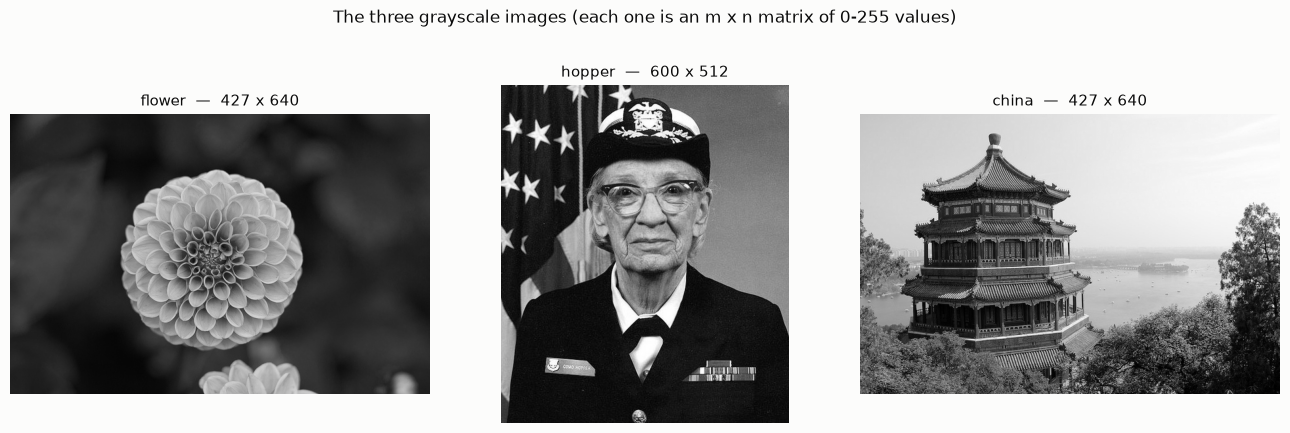

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, (name, img) in zip(axes, images.items()):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"{name}  —  {img.shape[0]} x {img.shape[1]}", fontsize=11)
    ax.grid(False)
    ax.axis("off")
fig.suptitle("The three grayscale images (each one is an m x n matrix of 0-255 values)",
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

In [4]:
# The matrix is not a metaphor - here are the actual numbers of an 8x8 patch of `hopper`.
patch = images["hopper"][300:308, 240:248]
print("images['hopper'][300:308, 240:248] =")
print(patch)
print("\ndtype:", patch.dtype, "| an image really is just a 2-D array of integers 0-255")

images['hopper'][300:308, 240:248] =
[[147 148 151 149 145 149 154 153]
 [142 148 147 148 153 145 138 145]
 [141 150 140 142 158 143 130 152]
 [131 140 123 126 152 139 130 167]
 [151 150 142 142 158 166 162 159]
 [182 176 160 152 162 166 158 154]
 [173 184 182 169 161 155 155 163]
 [168 185 190 182 173 160 151 152]]

dtype: uint8 | an image really is just a 2-D array of integers 0-255


## 2. Decompose the matrix using SVD

`np.linalg.svd(A, full_matrices=False)` returns the **thin** (economy) SVD: with
$r = \min(m, n)$ it gives $U \in \mathbb{R}^{m \times r}$, the vector of singular values
$s \in \mathbb{R}^{r}$, and $V^{\mathsf T} \in \mathbb{R}^{r \times n}$, such that
$A = U\,\mathrm{diag}(s)\,V^{\mathsf T}$ exactly. `full_matrices=True` would pad $U$ and
$V$ out to square orthogonal matrices whose extra columns are multiplied by zero singular
values — pure waste for our purposes.

The columns of $U$ and of $V$ are orthonormal ($U^{\mathsf T}U = V^{\mathsf T}V = I_r$),
and $s$ comes back sorted in non-increasing order. We check all of that numerically.

In [5]:
svd = {}
rows = []
for name, mat in A.items():
    t0 = time.perf_counter()
    U, s, Vt = np.linalg.svd(mat, full_matrices=False)
    elapsed = time.perf_counter() - t0
    svd[name] = (U, s, Vt)

    recon = (U * s) @ Vt                      # == U @ diag(s) @ Vt, but without the m x r temp
    rows.append({
        "image": name,
        "A.shape": mat.shape,
        "U.shape": U.shape,
        "s.shape": s.shape,
        "Vt.shape": Vt.shape,
        "svd time (s)": round(elapsed, 3),
        "||A - U S Vt||_F": f"{np.linalg.norm(mat - recon):.3e}",
        "||U^T U - I||": f"{np.linalg.norm(U.T @ U - np.eye(U.shape[1])):.2e}",
        "||V^T V - I||": f"{np.linalg.norm(Vt @ Vt.T - np.eye(Vt.shape[0])):.2e}",
        "s sorted desc": bool(np.all(np.diff(s) <= 1e-9)),
    })

pd.DataFrame(rows).set_index("image")

,A.shape,U.shape,s.shape,Vt.shape,svd time (s),||A - U S Vt||_F,||U^T U - I||,||V^T V - I||,s sorted desc
image,,,,,,,,,
flower,"(427, 640)","(427, 427)","(427,)","(427, 640)",6.618,3.279e-10,4.76e-14,4.31e-14,True
hopper,"(600, 512)","(600, 512)","(512,)","(512, 512)",8.592,4.553e-10,5.36e-14,5.59e-14,True
china,"(427, 640)","(427, 427)","(427,)","(427, 640)",7.705,8.522e-10,4.85e-14,4.58e-14,True


In [6]:
# The first few singular values, to see how steeply they fall off.
head = pd.DataFrame({name: svd[name][1][:8] for name in A}, index=[f"s_{i+1}" for i in range(8)])
print("Leading singular values")
print(head.round(1).to_string())
print("\nRatio to the first singular value s_1")
print(head.div(head.iloc[0]).round(4).to_string())

Leading singular values
      flower   hopper    china
s_1  40678.9  48975.4  83308.1
s_2  10028.0  12749.6  15365.4
s_3   8405.9  12232.6   9869.4
s_4   5072.2   9711.0   5794.3
s_5   3567.0   9040.3   4739.2
s_6   3282.2   6864.0   4168.9
s_7   3080.0   6305.0   3948.3
s_8   2680.3   5773.7   3397.9

Ratio to the first singular value s_1
     flower  hopper   china
s_1  1.0000  1.0000  1.0000
s_2  0.2465  0.2603  0.1844
s_3  0.2066  0.2498  0.1185
s_4  0.1247  0.1983  0.0696
s_5  0.0877  0.1846  0.0569
s_6  0.0807  0.1402  0.0500
s_7  0.0757  0.1287  0.0474
s_8  0.0659  0.1179  0.0408


## 3. Vary the rank and reconstruct

The rank-$k$ truncation keeps only the $k$ leading modes:

$$A_k = \sum_{i=1}^{k} \sigma_i\, u_i v_i^{\mathsf T} = U_{:,:k}\,\mathrm{diag}(s_{:k})\,V^{\mathsf T}_{:k,:}$$

Two numbers are reported on every panel below.

**Compression ratio.** Storing $A_k$ means storing $U_{:,:k}$ ($mk$ numbers),
$s_{:k}$ ($k$ numbers) and $V^{\mathsf T}_{:k,:}$ ($kn$ numbers) instead of the $mn$ pixels:

$$\mathrm{CR}(k) = \frac{k\,(m + n + 1)}{m\,n}$$

$\mathrm{CR} < 1$ means we store fewer numbers than the original; $\mathrm{CR} = 0.10$
means one tenth of the numbers.

**Relative Frobenius error.**

$$\varepsilon(k) = \frac{\lVert A - A_k \rVert_F}{\lVert A \rVert_F}$$

We sweep 10 ranks per image: `1, 2, 5, 10, 20, 50, 100, 150, 200` and the full rank
$\min(m, n)$, which reproduces the original exactly and serves as the reference panel.

In [7]:
def low_rank(name, k):
    """Best rank-k approximation of image `name` (Eckart-Young optimal)."""
    U, s, Vt = svd[name]
    return (U[:, :k] * s[:k]) @ Vt[:k, :]


def compression_ratio(name, k):
    m, n = A[name].shape
    return k * (m + n + 1) / (m * n)


def rel_error(name, k):
    """||A - A_k||_F / ||A||_F, computed from the spectrum (exact, and cheap)."""
    s = svd[name][1]
    return float(np.sqrt(np.sum(s[k:] ** 2) / np.sum(s ** 2)))


def break_even_k(name):
    """Smallest k for which the factors cost at least as many numbers as the pixels."""
    m, n = A[name].shape
    return int(np.ceil(m * n / (m + n + 1)))


RANKS = [1, 2, 5, 10, 20, 50, 100, 150, 200]
ranks_for = {name: RANKS + [min(A[name].shape)] for name in A}

for name in A:
    print(f"{name:7s} full rank = {min(A[name].shape):3d} | "
          f"break-even k (CR = 1) = {break_even_k(name):3d} | ranks = {ranks_for[name]}")

flower  full rank = 427 | break-even k (CR = 1) = 256 | ranks = [1, 2, 5, 10, 20, 50, 100, 150, 200, 427]
hopper  full rank = 512 | break-even k (CR = 1) = 277 | ranks = [1, 2, 5, 10, 20, 50, 100, 150, 200, 512]
china   full rank = 427 | break-even k (CR = 1) = 256 | ranks = [1, 2, 5, 10, 20, 50, 100, 150, 200, 427]


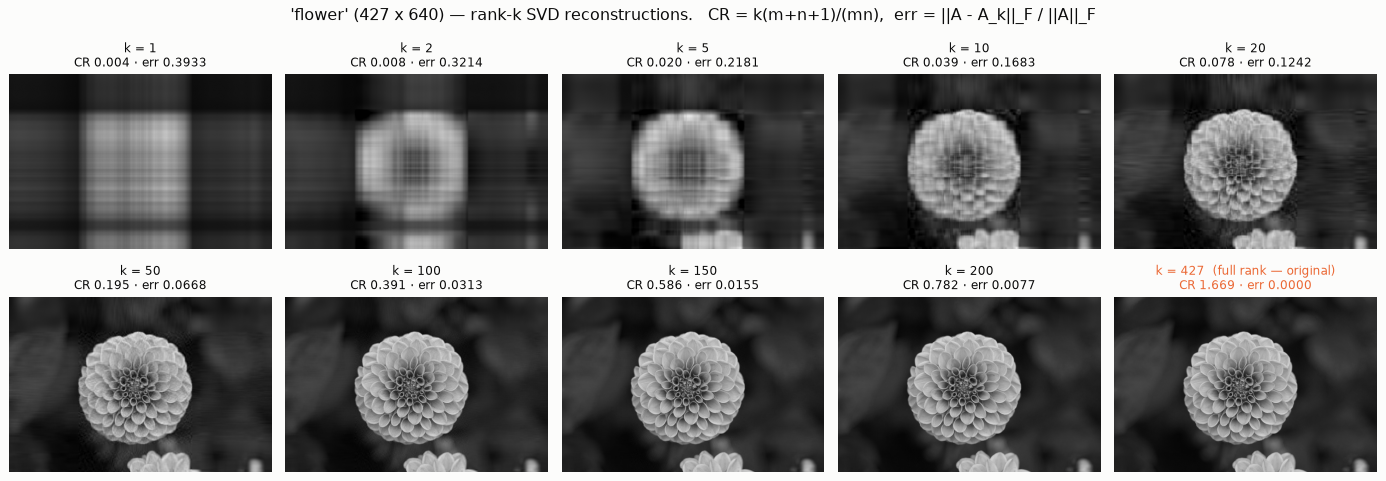

In [8]:
def plot_rank_sweep(name):
    """2 x 5 grid of rank-k reconstructions, one panel per rank."""
    ranks = ranks_for[name]
    full = min(A[name].shape)
    m, n = A[name].shape

    # Size the figure to the image aspect ratio so the panels tile without dead space.
    fig_w = 15.5
    panel_w = fig_w / 5
    panel_h = panel_w * m / n
    fig_h = 2 * panel_h + 1.6                      # + room for the titles

    fig, axes = plt.subplots(2, 5, figsize=(fig_w, fig_h), dpi=90)
    for ax, k in zip(axes.ravel(), ranks):
        ax.imshow(np.clip(low_rank(name, k), 0, 255), cmap="gray", vmin=0, vmax=255)
        tag = f"k = {k}" + ("  (full rank — original)" if k == full else "")
        ax.set_title(
            f"{tag}\nCR {compression_ratio(name, k):.3f} · err {rel_error(name, k):.4f}",
            fontsize=9.5, color=INK if k != full else C_ORANGE,
        )
        ax.grid(False)
        ax.axis("off")
    fig.suptitle(
        f"'{name}' ({m} x {n}) — rank-k SVD reconstructions.   "
        f"CR = k(m+n+1)/(mn),  err = ||A - A_k||_F / ||A||_F",
        fontsize=12.5,
    )
    plt.tight_layout()
    plt.show()


plot_rank_sweep("flower")

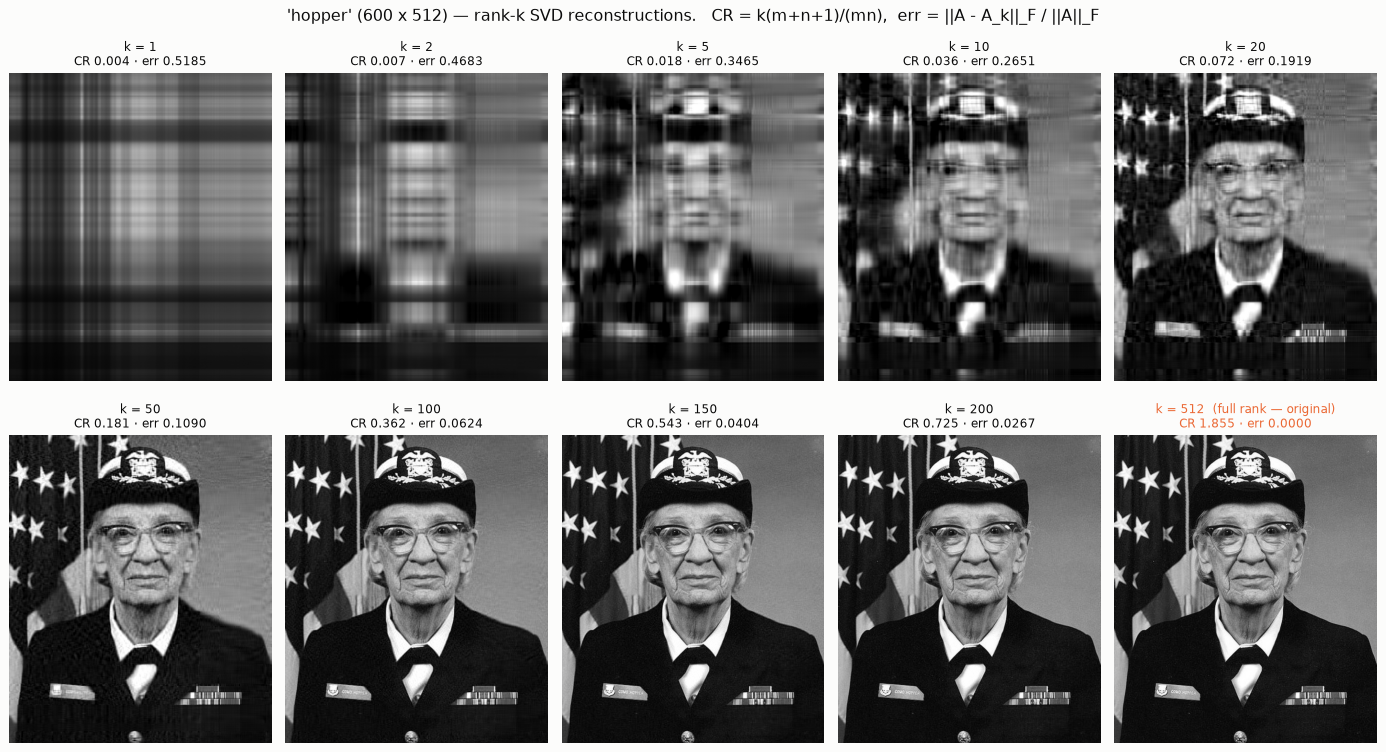

In [9]:
plot_rank_sweep("hopper")

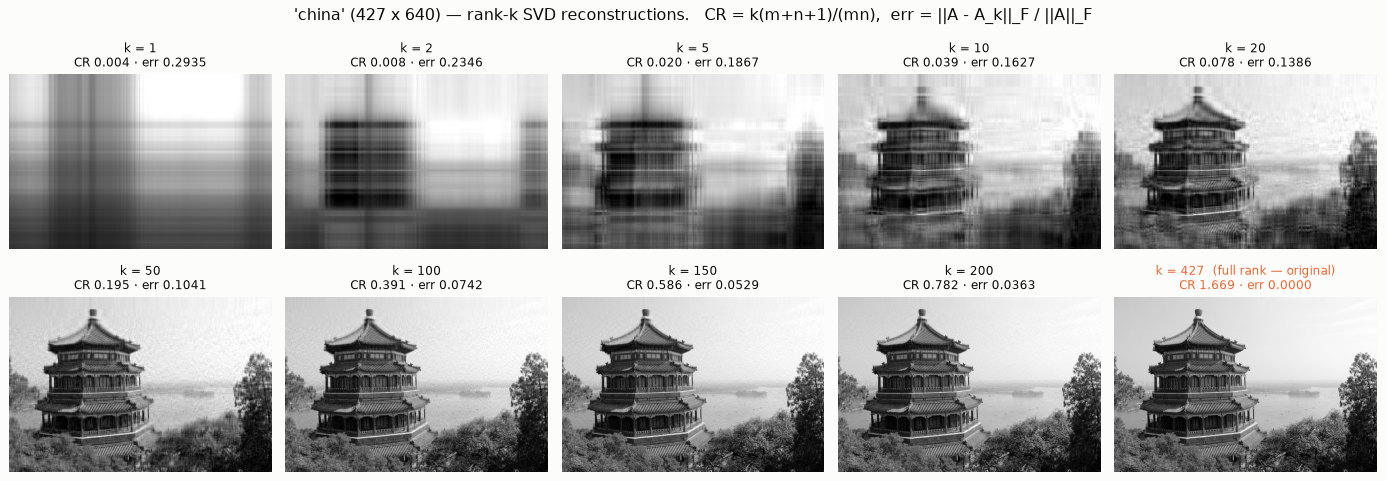

In [10]:
plot_rank_sweep("china")

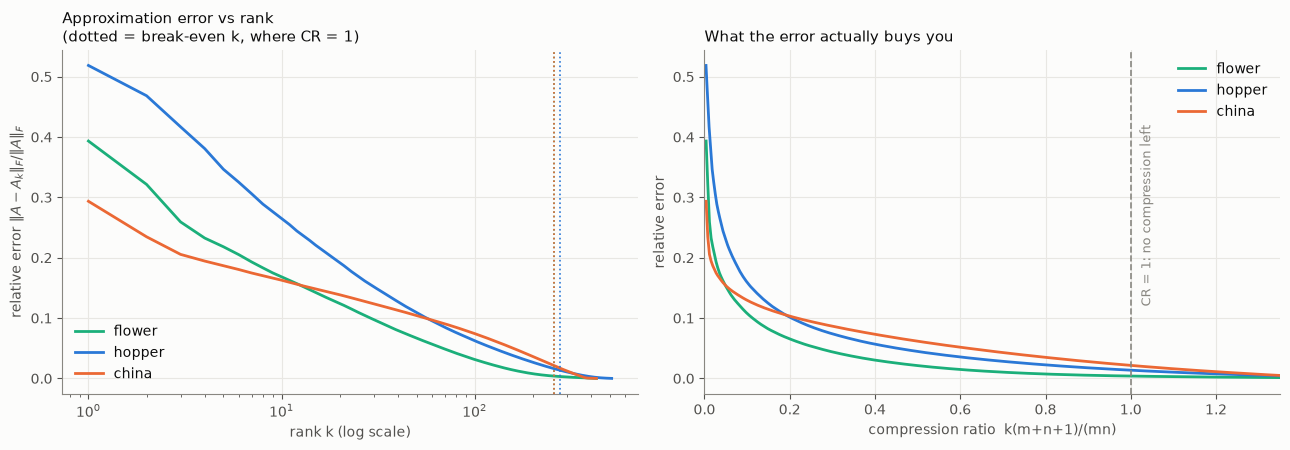

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

for name in A:
    kk = np.arange(1, min(A[name].shape) + 1)
    err = np.array([rel_error(name, int(k)) for k in kk])
    axes[0].plot(kk, err, color=COLORS[name], lw=2, label=name)
    cr = np.array([compression_ratio(name, int(k)) for k in kk])
    axes[1].plot(cr, err, color=COLORS[name], lw=2, label=name)

for name in A:
    be = break_even_k(name)
    axes[0].axvline(be, color=COLORS[name], ls=":", lw=1.2)
axes[0].set_xscale("log")
axes[0].set_xlabel("rank k (log scale)")
axes[0].set_ylabel(r"relative error $\|A-A_k\|_F/\|A\|_F$")
axes[0].set_title("Approximation error vs rank\n(dotted = break-even k, where CR = 1)",
                  loc="left", fontsize=11)
axes[0].legend(frameon=False)

axes[1].axvline(1.0, color=MUTED, ls="--", lw=1.2)
axes[1].text(1.02, 0.42, "CR = 1: no compression left", color=MUTED, fontsize=9, rotation=90,
             va="top")
axes[1].set_xlabel("compression ratio  k(m+n+1)/(mn)")
axes[1].set_ylabel("relative error")
axes[1].set_title("What the error actually buys you", loc="left", fontsize=11)
axes[1].set_xlim(0, 1.35)
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

## What does the singular value spectrum look like?

We plot the singular values $\sigma_i$ on a logarithmic $y$-axis — on a linear axis
everything after the first handful of modes is visually indistinguishable from zero, which
is itself the point.

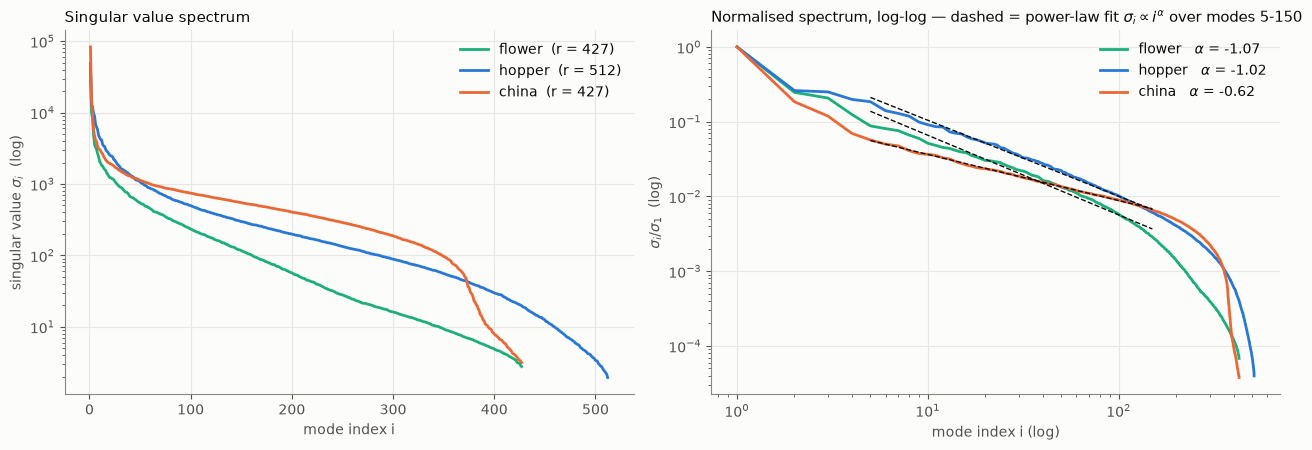

Power-law exponent of the mid-spectrum (more negative = faster decay = easier to compress):
  flower  alpha = -1.07
  hopper  alpha = -1.02
  china   alpha = -0.62


,s_1,s_1 / s_2,s_1 / s_10,s_1 / s_100,s_1 / s_last,power-law alpha,share of energy in mode 1
image,,,,,,,
flower,40678.9,4.1,19.5,174.2,14661.5,-1.07,0.8453
hopper,48975.4,3.8,11.0,98.2,25129.3,-1.02,0.7311
china,83308.1,5.4,27.4,111.3,26437.0,-0.62,0.9139


In [12]:
FIT_LO, FIT_HI = 5, 150          # mode range used for the power-law fit

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
slopes = {}
for name in A:
    s = svd[name][1]
    idx = np.arange(1, len(s) + 1)
    axes[0].semilogy(idx, s, color=COLORS[name], lw=2, label=f"{name}  (r = {len(s)})")

    # Fit sigma_i ~ i^alpha on a log-log scale over a mid-range window.
    i_fit = np.arange(FIT_LO, FIT_HI + 1)
    alpha, intercept = np.polyfit(np.log10(i_fit), np.log10(s[FIT_LO - 1:FIT_HI]), 1)
    slopes[name] = alpha

    axes[1].loglog(idx, s / s[0], color=COLORS[name], lw=2,
                   label=rf"{name}   $\alpha$ = {alpha:.2f}")
    axes[1].loglog(i_fit, 10 ** (intercept + alpha * np.log10(i_fit)) / s[0],
                   color=INK, ls="--", lw=1.0, zorder=5)

axes[0].set_xlabel("mode index i")
axes[0].set_ylabel(r"singular value $\sigma_i$  (log)")
axes[0].set_title("Singular value spectrum", loc="left", fontsize=11)
axes[0].legend(frameon=False)

axes[1].set_xlabel("mode index i (log)")
axes[1].set_ylabel(r"$\sigma_i / \sigma_1$  (log)")
axes[1].set_title(rf"Normalised spectrum, log-log — dashed = power-law fit "
                  rf"$\sigma_i \propto i^{{\alpha}}$ over modes {FIT_LO}-{FIT_HI}",
                  loc="left", fontsize=10.5)
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

print("Power-law exponent of the mid-spectrum (more negative = faster decay = "
      "easier to compress):")
for name, a in slopes.items():
    print(f"  {name:7s} alpha = {a:+.2f}")

spec = pd.DataFrame(
    [
        {
            "image": name,
            "s_1": round(float(svd[name][1][0]), 1),
            "s_1 / s_2": round(float(svd[name][1][0] / svd[name][1][1]), 1),
            "s_1 / s_10": round(float(svd[name][1][0] / svd[name][1][9]), 1),
            "s_1 / s_100": round(float(svd[name][1][0] / svd[name][1][99]), 1),
            "s_1 / s_last": round(float(svd[name][1][0] / svd[name][1][-1]), 1),
            "power-law alpha": round(float(slopes[name]), 2),
            "share of energy in mode 1": round(
                float(svd[name][1][0] ** 2 / np.sum(svd[name][1] ** 2)), 4),
        }
        for name in A
    ]
).set_index("image")
spec

### Reading the spectrum

* **One giant value, then a cliff.** $\sigma_1$ is 4–5x larger than $\sigma_2$ and carries
  73 % (`hopper`), 85 % (`flower`) and 91 % (`china`) of the total squared energy *on its
  own*. That mode is essentially the *average brightness* of the picture: the rank-one
  matrix $\sigma_1 u_1 v_1^{\mathsf T}$ is close to a constant grey field modulated by the
  coarse light/dark layout, which is why the $k = 1$ panels above look like a smear of
  horizontal and vertical bands rather than a scene.
* **Rapid decay over the first few dozen modes.** By mode 20 the singular values have
  dropped by a factor of 19–43, and by mode 100 by a factor of 98–174. This is where the
  actual structure of the image lives.
* **A long tail that follows a power law.** On the log-log axis the mid-spectrum
  (modes 5–150) is close to a straight line, i.e. $\sigma_i \propto i^{\alpha}$; the fitted
  exponents are $\alpha \approx -1.07$ (`flower`), $-1.02$ (`hopper`) and $-0.62$ (`china`).
  The tail is fine texture and sensor noise. It never reaches zero — the matrix is formally
  of full rank $\min(m, n)$ — but by the last mode the values are ~4 orders of magnitude
  below $\sigma_1$.
* **The textured image decays the slowest, and the exponent says so quantitatively.**
  `china`'s $\alpha = -0.62$ against `flower`'s $-1.07$ means its spectrum falls off at
  roughly half the log-log rate: high-frequency detail spreads energy across many more
  modes. This single number predicts everything we see later — `china` needs ~2.5x the
  rank of `flower` for the same explained variance.

**Why low-rank approximation works at all.** By Eckart–Young the error of the truncation
is $\lVert A - A_k \rVert_F^2 = \sum_{i > k} \sigma_i^2$ — the *discarded* part of the
spectrum. Because the spectrum drops so fast, that tail sum is tiny even for modest $k$:
throwing away 90 % of the modes throws away a few percent of the energy. Equivalently: rows
(and columns) of a photograph are strongly correlated with their neighbours, so the matrix
is far from having $\min(m,n)$ "independent" rows, and the SVD is the tool that exposes
exactly how far.

## 4. Explained variance versus rank

### What "explained variance" means here

Since $U$ and $V$ have orthonormal columns, the Frobenius norm of $A$ is carried entirely
by the singular values:

$$\lVert A \rVert_F^2 = \sum_{i,j} A_{ij}^2 = \sum_{i=1}^{r} \sigma_i^2 .$$

So the total "energy" of the matrix splits into one non-negative contribution
$\sigma_i^2$ per mode, and the **explained-variance ratio of mode $i$** is its share of
that total:

$$\mathrm{EVR}_i = \frac{\sigma_i^2}{\sum_{j} \sigma_j^2},
\qquad
\mathrm{EV}(k) = \sum_{i \le k} \mathrm{EVR}_i
= \frac{\sum_{i \le k} \sigma_i^2}{\sum_{j} \sigma_j^2} .$$

Eckart–Young ties this straight to reconstruction quality:

$$\lVert A - A_k \rVert_F^2 = \sum_{i > k} \sigma_i^2
\quad\Longrightarrow\quad
\mathrm{EV}(k) = 1 - \frac{\lVert A - A_k \rVert_F^2}{\lVert A \rVert_F^2}
= 1 - \varepsilon(k)^2 .$$

In words: **$\mathrm{EV}(k)$ is the fraction of the image's total squared energy that
survives the rank-$k$ truncation**, and $1 - \mathrm{EV}(k)$ is exactly the squared
relative error we printed on the reconstruction panels. `flower` reaches 95 % of its
uncentred energy at $k = 5$, which therefore has to mean a relative Frobenius error of
$\sqrt{1 - 0.95} \approx 22\,\%$ — and indeed the $k = 5$ panel above is labelled
`err 0.2181`.

### The caveat that the word "variance" hides

Strictly, $\sum_i \sigma_i^2$ is the **uncentred** sum of squares of the raw pixel values,
not a variance. It equals a variance only if the matrix has been mean-centred first. For an
image the mean is *large* (`china` has mean pixel value 145), so the uncentred energy is
dominated by the constant-brightness component: $\mathrm{EV}(1)$ is already 0.73–0.91, and
for `china` a *single* mode clears the 90 % bar. Flattering, but it says nothing about how
much *detail* has been kept.

PCA (`sklearn.decomposition.PCA`) subtracts the column means before its SVD, and its
`explained_variance_ratio_` is $\sigma_i^2 / \sum_j \sigma_j^2$ computed on the **centred**
matrix. That is the number people usually mean by "explained variance", and it is far more
discriminating here. We plot **both** below and verify the PCA identity numerically.

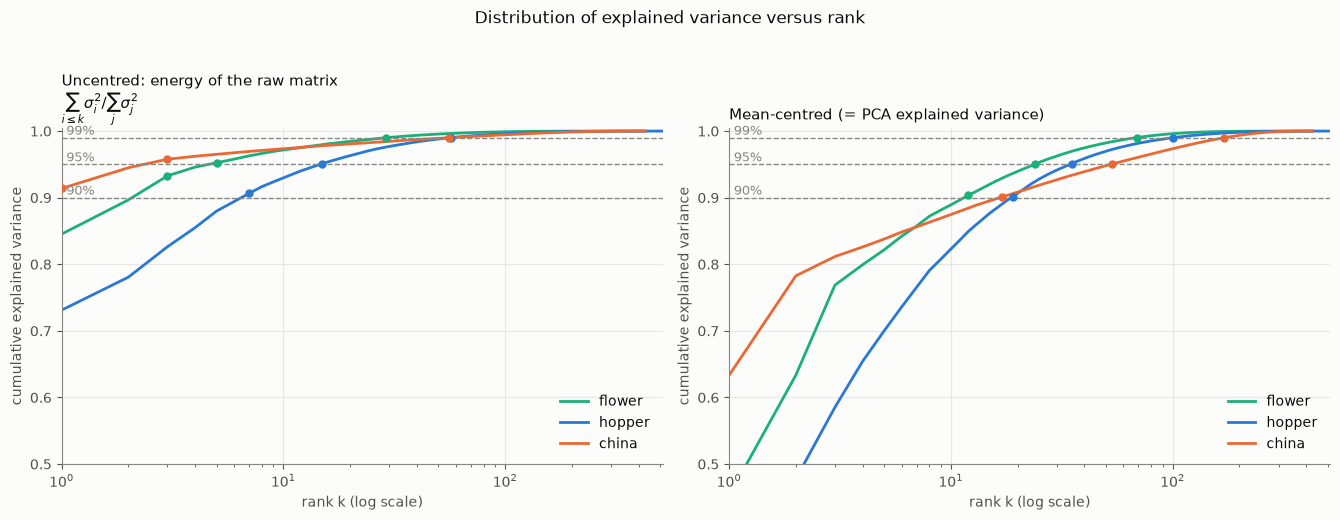

In [13]:
def explained_variance_curve(mat, center=False):
    """Cumulative explained-variance ratio vs rank."""
    M = mat - mat.mean(axis=0, keepdims=True) if center else mat
    s = np.linalg.svd(M, compute_uv=False)
    return np.cumsum(s ** 2) / np.sum(s ** 2)


ev_raw = {name: explained_variance_curve(A[name], center=False) for name in A}
ev_cen = {name: explained_variance_curve(A[name], center=True) for name in A}

THRESHOLDS = (0.90, 0.95, 0.99)


def rank_for(curve, thr):
    """Smallest k with EV(k) >= thr (1-based)."""
    return int(np.searchsorted(curve, thr) + 1)


fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))
for ax, curves, title in (
    (axes[0], ev_raw, "Uncentred: energy of the raw matrix\n" r"$\sum_{i\leq k}\sigma_i^2 / \sum_j \sigma_j^2$"),
    (axes[1], ev_cen, "Mean-centred (= PCA explained variance)"),
):
    for name in A:
        c = curves[name]
        ax.plot(np.arange(1, len(c) + 1), c, color=COLORS[name], lw=2, label=name)
    for thr in THRESHOLDS:
        ax.axhline(thr, color=MUTED, ls="--", lw=1.0)
        ax.text(1.05, thr, f"{thr:.0%}", color=MUTED, fontsize=9, va="bottom")
    for name in A:
        c = curves[name]
        for thr in THRESHOLDS:
            k = rank_for(c, thr)
            ax.plot([k], [c[k - 1]], "o", color=COLORS[name], ms=5, zorder=5)
    ax.set_xscale("log")
    ax.set_xlim(1, max(len(c) for c in curves.values()))
    ax.set_ylim(0.5, 1.005)
    ax.set_xlabel("rank k (log scale)")
    ax.set_ylabel("cumulative explained variance")
    ax.set_title(title, loc="left", fontsize=11)
    ax.legend(frameon=False, loc="lower right")

fig.suptitle("Distribution of explained variance versus rank", y=1.03, fontsize=12.5)
plt.tight_layout()
plt.show()

In [14]:
rows = []
for name in A:
    m, n = A[name].shape
    row = {"image": name, "shape": f"{m} x {n}", "full rank": min(m, n)}
    for thr in THRESHOLDS:
        k_raw = rank_for(ev_raw[name], thr)
        k_cen = rank_for(ev_cen[name], thr)
        row[f"k @ {thr:.0%} (uncentred)"] = k_raw
        row[f"k @ {thr:.0%} (centred/PCA)"] = k_cen
        row[f"CR @ {thr:.0%} (centred)"] = round(compression_ratio(name, k_cen), 3)
    row["break-even k (CR=1)"] = break_even_k(name)
    rows.append(row)

ev_table = pd.DataFrame(rows).set_index("image")
cols = (["shape", "full rank"]
        + [f"k @ {t:.0%} (uncentred)" for t in THRESHOLDS]
        + [f"k @ {t:.0%} (centred/PCA)" for t in THRESHOLDS]
        + [f"CR @ {t:.0%} (centred)" for t in THRESHOLDS]
        + ["break-even k (CR=1)"])
ev_table = ev_table[cols]
print("Ranks needed to reach each explained-variance threshold\n")
print(ev_table.to_string())

Ranks needed to reach each explained-variance threshold

            shape  full rank  k @ 90% (uncentred)  k @ 95% (uncentred)  k @ 99% (uncentred)  k @ 90% (centred/PCA)  k @ 95% (centred/PCA)  k @ 99% (centred/PCA)  CR @ 90% (centred)  CR @ 95% (centred)  CR @ 99% (centred)  break-even k (CR=1)
image                                                                                                                                                                                                                                            
flower  427 x 640        427                    3                    5                   29                     12                     24                     69               0.047               0.094               0.270                  256
hopper  600 x 512        512                    7                   15                   57                     19                     35                    100               0.069               0.127               0.

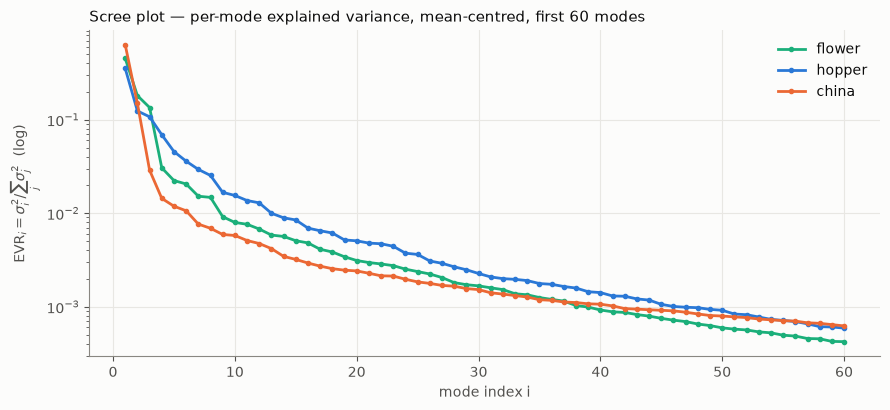

In [15]:
# Per-mode (not cumulative) explained-variance ratio - the "scree plot".
fig, ax = plt.subplots(figsize=(9, 4.2))
for name in A:
    s = np.linalg.svd(A[name] - A[name].mean(axis=0, keepdims=True), compute_uv=False)
    evr = s ** 2 / np.sum(s ** 2)
    ax.semilogy(np.arange(1, 61), evr[:60], color=COLORS[name], lw=2, marker="o", ms=3,
                label=name)
ax.set_xlabel("mode index i")
ax.set_ylabel(r"$\mathrm{EVR}_i = \sigma_i^2/\sum_j\sigma_j^2$  (log)")
ax.set_title("Scree plot — per-mode explained variance, mean-centred, first 60 modes",
             loc="left", fontsize=11)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [16]:
# Verify the claim that PCA's explained_variance_ratio_ IS sigma_i^2 / sum sigma_j^2
# of the column-centred matrix. svd_solver="full" so we compare exact against exact
# (the default "auto" would pick the randomized solver here, which is only approximate).
name = "hopper"
k = 20
pca = PCA(n_components=k, svd_solver="full", random_state=RANDOM_STATE).fit(A[name])
s_cen = np.linalg.svd(A[name] - A[name].mean(axis=0, keepdims=True), compute_uv=False)
manual = (s_cen ** 2 / np.sum(s_cen ** 2))[:k]

print(f"PCA on '{name}' (rows = samples, columns = features), n_components = {k}")
print("max |PCA.explained_variance_ratio_ - sigma_i^2/sum sigma_j^2| =",
      f"{np.max(np.abs(pca.explained_variance_ratio_ - manual)):.3e}")
print("allclose:", np.allclose(pca.explained_variance_ratio_, manual))

print("\nAnd PCA's eigenvalues are sigma_i^2/(m-1):")
eig = s_cen[:k] ** 2 / (A[name].shape[0] - 1)
print("max relative difference:",
      f"{np.max(np.abs(pca.explained_variance_ - eig) / eig):.3e}")
print("allclose:", np.allclose(pca.explained_variance_, eig))

PCA on 'hopper' (rows = samples, columns = features), n_components = 20
max |PCA.explained_variance_ratio_ - sigma_i^2/sum sigma_j^2| = 4.441e-16
allclose: True

And PCA's eigenvalues are sigma_i^2/(m-1):
max relative difference: 3.543e-15
allclose: True


## Numerical check of the Eckart–Young theorem

The theorem makes two claims, and both are easy to test:

1. **The error is the discarded tail of the spectrum:**
   $\lVert A - A_k \rVert_F^2 = \sum_{i > k} \sigma_i^2$.
2. **No other rank-$k$ matrix does better:** $A_k$ minimises $\lVert A - B \rVert_F$ over
   all $B$ with $\mathrm{rank}(B) \le k$.

For claim 2 we build an honest competitor: project $A$ onto a *random* $k$-dimensional
subspace, $B = QQ^{\mathsf T}A$ with $Q$ an orthonormal basis of a random subspace. That is
the best rank-$k$ approximation *within that random subspace*, so it is a much stronger
baseline than a matrix of random entries — and it still has to lose.

In [17]:
check_rows = []
for name in A:
    s = svd[name][1]
    for k in (1, 5, 20, 50, 150):
        Ak = low_rank(name, k)
        lhs = float(np.linalg.norm(A[name] - Ak) ** 2)   # ||A - A_k||_F^2
        rhs = float(np.sum(s[k:] ** 2))                  # sum_{i>k} sigma_i^2
        check_rows.append({
            "image": name, "k": k,
            "||A - A_k||_F^2": f"{lhs:.6e}",
            "sum_{i>k} s_i^2": f"{rhs:.6e}",
            "rel. difference": f"{abs(lhs - rhs) / rhs:.2e}",
            "allclose": bool(np.isclose(lhs, rhs, rtol=1e-9, atol=0.0)),
        })

ey = pd.DataFrame(check_rows).set_index(["image", "k"])
print("Eckart-Young, claim 1:  ||A - A_k||_F^2 == sum_{i>k} sigma_i^2\n")
print(ey.to_string())
print("\nall rows pass:", bool(ey["allclose"].all()))

Eckart-Young, claim 1:  ||A - A_k||_F^2 == sum_{i>k} sigma_i^2

           ||A - A_k||_F^2 sum_{i>k} s_i^2 rel. difference  allclose
image  k                                                            
flower 1      3.027992e+08    3.027992e+08        0.00e+00      True
       5      9.312827e+07    9.312827e+07        0.00e+00      True
       20     3.020313e+07    3.020313e+07        2.47e-16      True
       50     8.728598e+06    8.728598e+06        4.27e-16      True
       150    4.715753e+05    4.715753e+05        1.23e-16      True
hopper 1      8.820959e+08    8.820959e+08        1.35e-16      True
       5      3.938780e+08    3.938780e+08        3.03e-16      True
       20     1.207832e+08    1.207832e+08        3.70e-16      True
       50     3.897160e+07    3.897160e+07        0.00e+00      True
       150    5.351633e+06    5.351633e+06        3.48e-16      True
china  1      6.541399e+08    6.541399e+08        1.82e-15      True
       5      2.646055e+08    2.646055e

In [18]:
print("Eckart-Young, claim 2: no rank-k matrix beats the truncated SVD")
print("(competitor = projection of A onto a random k-dimensional subspace, "
      "best of 5 draws)\n")

comp_rows = []
for name in A:
    m, n = A[name].shape
    normA = np.linalg.norm(A[name])
    for k in (5, 20, 50):
        svd_err = np.linalg.norm(A[name] - low_rank(name, k)) / normA
        best_rand = np.inf
        for _ in range(5):
            Q, _ = np.linalg.qr(rng.standard_normal((m, k)))
            B = Q @ (Q.T @ A[name])              # rank <= k
            best_rand = min(best_rand, np.linalg.norm(A[name] - B) / normA)
        comp_rows.append({
            "image": name, "k": k,
            "SVD rank-k err": round(svd_err, 4),
            "random-subspace err": round(best_rand, 4),
            "SVD better": bool(svd_err <= best_rand + 1e-12),
            "times worse": round(best_rand / svd_err, 2),
        })

comp = pd.DataFrame(comp_rows).set_index(["image", "k"])
print(comp.to_string())
print("\nSVD wins every time:", bool(comp["SVD better"].all()))

Eckart-Young, claim 2: no rank-k matrix beats the truncated SVD
(competitor = projection of A onto a random k-dimensional subspace, best of 5 draws)



           SVD rank-k err  random-subspace err  SVD better  times worse
image  k                                                               
flower 5           0.2181               0.9869        True         4.52
       20          0.1242               0.9701        True         7.81
       50          0.0668               0.9232        True        13.83
hopper 5           0.3465               0.9946        True         2.87
       20          0.1919               0.9726        True         5.07
       50          0.1090               0.9537        True         8.75
china  5           0.1867               0.9935        True         5.32
       20          0.1386               0.9620        True         6.94
       50          0.1041               0.9162        True         8.80

SVD wins every time: True


## Answers

### How many modes are needed for good image reconstruction?

There is no single number — it depends on the image and on what "good" means. Three
answers, from strictest to most practical.

**By energy** (the table above, mean-centred / PCA convention, with the compression ratio
that rank implies):

| image | 90 % | 95 % | 99 % | CR at 99 % |
|---|---|---|---|---|
| `flower` (427x640, smooth)   | 12 | 24 | 69  | 0.270 |
| `hopper` (600x512, portrait) | 19 | 35 | 100 | 0.362 |
| `china`  (427x640, textured) | 17 | 53 | 171 | 0.668 |

On the raw, **uncentred** matrix the same thresholds land at $k$ = 3 / 5 / 29 (`flower`),
7 / 15 / 57 (`hopper`) and 1 / 3 / 56 (`china`) — flatteringly small, because the first
mode is mostly mean brightness. That is the caveat discussed above, and it is why the
centred numbers are the ones to quote.

**By eye** (from the rank sweeps):

* $k = 1\!-\!2$ — a smear of horizontal and vertical bands; no recognisable content in any
  of the three.
* $k = 5\!-\!10$ — the scene becomes recognisable everywhere: `flower` shows a clear
  blossom, `china` a clear pagoda silhouette, `hopper` a human figure but not yet a face.
* $k = 20$ — `flower` is already close to acceptable (little detail to lose in an
  out-of-focus background); `hopper`'s face is identifiable but streaked; `china`'s
  architecture is sharp while the foliage is still mush.
* $k = 50$ — `flower` is essentially done (err 6.7 %); `hopper` is good apart from fine
  fabric and insignia (err 10.9 %); `china` still shows visible ringing and a grainy tree
  line (err 10.4 %).
* $k = 100\!-\!150$ — `hopper` and `flower` are hard to tell from the original; `china`
  finally converges, with the leaves the last thing to sharpen.
* Beyond $k = 200$ nothing visible changes while storage is already ~78 % of the original —
  a bad trade.

A rule of thumb from these three images: **~5 % of the full rank gives a recognisable
image, ~10 % a decent one, and ~25–35 % is visually lossless.**

**Why the textured image needs more modes.** Each rank-one term
$\sigma_i u_i v_i^{\mathsf T}$ is a *separable* pattern — an outer product, i.e. one
horizontal profile times one vertical profile. Smooth, large-scale structure is well
described by a handful of such patterns, so `flower`, whose background is a low-frequency
blur, is captured almost immediately. High-frequency, non-separable texture — the leaves
and ornate carvings of `china` — has no compact separable description, so its energy is
spread thinly over hundreds of modes. This is visible in three independent places: the
flatter power-law exponent ($\alpha = -0.62$ vs $-1.07$), the fatter tail of the spectrum
plot, and the slower error decay — at $k = 50$, `flower` sits at 6.7 % relative error while
`china` is still at 10.4 %, and `china` needs $k = 171$ against `flower`'s $k = 69$ to
reach 99 %.

Note that `hopper` beats `china` on the 99 % criterion but loses on the 90 % one. The
portrait has a strong, simple global layout (dark uniform, bright flag) that a few modes
capture, but genuinely fine detail — the face, the medals — that takes many; `china` is the
opposite, a near-uniform bright sky that one mode nails followed by texture everywhere.
Rank requirements are not a single ranking of "image complexity"; they depend on the
threshold you pick.

### Where compression stops being a win

$\mathrm{CR}(k) = k(m + n + 1)/(mn) \ge 1$ once

$$k \ge \frac{mn}{m + n + 1}.$$

For the 427x640 images that is $k \ge 256$, and for 600x512 it is $k \ge 277$ — roughly
55–60 % of the full rank in both cases. Past that point the factors $U_k$, $s_k$,
$V_k^{\mathsf T}$ occupy *more* numbers than the pixels they approximate, so the
"compression" is a pure loss. (The full-rank panels in the sweeps are labelled CR 1.669 and
CR 1.855 — perfect reconstruction at nearly twice the storage.) Since all three images are
visually converged well before $k = 200$, the useful operating range is comfortably on the
profitable side.

One honest footnote: the formula counts **numbers**, not **bytes**. The original pixels are
`uint8` (1 byte each) while $U$, $s$, $V^{\mathsf T}$ come out as `float64` (8 bytes each),
so in actual bytes the break-even arrives 8x earlier — at $k \approx 32$ for the 427x640
images and $k \approx 35$ for `hopper`, i.e. right in the middle of the range where quality
is still improving. To make SVD a genuine byte-level compressor you would have to quantise
the factors back down to 8–16 bits. This is also why practical codecs (JPEG) use a *fixed*
DCT basis plus quantisation instead of a per-image SVD: with SVD you must ship the basis
vectors $U_k$ and $V_k$ along with the coefficients, and that basis is most of the cost.

### What the singular value spectrum looks like — short answer

Extremely top-heavy. $\sigma_1$ alone holds 73–91 % of the uncentred squared energy and is
4–5x larger than $\sigma_2$; the values then fall by a factor of ~100 over the first 100
modes and continue into a long power-law tail $\sigma_i \propto i^{\alpha}$ with
$\alpha \approx -1$ (and only $-0.62$ for the textured `china`), ending ~4 orders of
magnitude below $\sigma_1$ without ever reaching zero. That steep, concentrated spectrum is
precisely why truncating it costs so little: by Eckart–Young the squared error *is* the
discarded tail, $\sum_{i>k}\sigma_i^2$.

In [19]:
print(f"Notebook runtime: {time.perf_counter() - NB_START:.1f} s")
print("Saved grayscale inputs:", sorted(p.name for p in DATA_DIR.glob("gray_*.png")))

Notebook runtime: 73.6 s
Saved grayscale inputs: ['gray_china.png', 'gray_flower.png', 'gray_hopper.png']
